# Laboratorio 7 — Regresión Logística
**SmartStay Advisors — Airbnb listings**

Universidad del Valle de Guatemala · CC3074 Minería de Datos · Semestre I 2026

## Inciso 1 — Variables dicotómicas por categoría de precio

Se pide construir **tres variables dicotómicas (0/1)** a partir de la variable respuesta categórica `price_category` creada en los laboratorios anteriores:

- `es_cara` → 1 si la vivienda es *cara*, 0 en cualquier otro caso.
- `es_media` → 1 si la vivienda es de precio *medio*, 0 en cualquier otro caso.
- `es_economica` → 1 si la vivienda es *económica*, 0 en cualquier otro caso.

Para mantener la reproducibilidad respecto a laboratorios previos se reutilizan los **mismos cortes por tercios (q1 = 33%, q2 = 66%)** sobre `price_num` y las mismas etiquetas usadas en el lab anterior.

In [2]:
# Librerías base para carga de datos y manipulación tabular
import pyreadr
import pandas as pd
import numpy as np

# Semilla fija para reproducibilidad en pasos posteriores del laboratorio
SEED = 42
np.random.seed(SEED)

In [3]:
# Lectura del RData original de listings (mismo archivo usado en labs anteriores)
result = pyreadr.read_r("listings.RData")
df = result["listings"].copy()

# Tamaño original del dataset antes de cualquier limpieza
print(f"Filas y columnas del dataset original: {df.shape}")

Filas y columnas del dataset original: (171748, 80)


In [4]:
# Normalización de la columna `price` a numérico, replicando la limpieza
# ya validada en los laboratorios previos: se remueven símbolos de moneda y
# separadores de miles, se tratan strings vacíos como nulos y se descartan
# filas sin precio (no se pueden clasificar sin la variable objetivo).
filas_antes = len(df)

df["price_num"] = (
    df["price"].astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)
df["price_num"] = df["price_num"].replace({"nan": np.nan, "None": np.nan, "": np.nan})
df["price_num"] = pd.to_numeric(df["price_num"], errors="coerce")
df = df.dropna(subset=["price_num"]).copy()

print(f"Filas antes de limpiar precio: {filas_antes:,}")
print(f"Filas con precio válido:       {len(df):,}")

Filas antes de limpiar precio: 171,748
Filas con precio válido:       76,246


In [5]:
# Cortes por tercios sobre price_num: mismos umbrales usados en el lab anterior
# para construir la variable categórica de precio. Se usan tercios (33%-66%)
# para obtener tres grupos balanceados en cantidad de observaciones.
q1, q2 = df["price_num"].quantile([1/3, 2/3])
print(f"q1 (percentil 33) = {q1:.2f}")
print(f"q2 (percentil 66) = {q2:.2f}")

# Construcción de la variable categórica de precio (3 niveles)
df["price_category"] = pd.cut(
    df["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["economica", "media", "cara"],
    include_lowest=True,
)

# Conteo por categoría para verificar balance
print("\nDistribución de price_category:")
print(df["price_category"].value_counts())

q1 (percentil 33) = 143.00
q2 (percentil 66) = 268.00

Distribución de price_category:
price_category
economica    25689
cara         25404
media        25153
Name: count, dtype: int64


In [6]:
# Creación de las tres variables dicotómicas pedidas en el inciso 1.
# Cada una es 1 cuando la observación pertenece a esa categoría, 0 en caso contrario.
df["es_cara"]      = (df["price_category"] == "cara").astype(int)
df["es_media"]     = (df["price_category"] == "media").astype(int)
df["es_economica"] = (df["price_category"] == "economica").astype(int)

# Resumen: totales y proporción de 1s por cada variable dicotómica
resumen = pd.DataFrame({
    "total_1s":  df[["es_cara", "es_media", "es_economica"]].sum(),
    "proporcion": df[["es_cara", "es_media", "es_economica"]].mean().round(4),
})
print(resumen)

# Chequeo de integridad: las tres variables deben ser mutuamente excluyentes
# y colectivamente exhaustivas, es decir, la suma por fila siempre debe ser 1.
suma_filas_ok = (df[["es_cara", "es_media", "es_economica"]].sum(axis=1) == 1).all()
print(f"\n¿Cada fila pertenece a exactamente 1 categoría? {suma_filas_ok}")

# Vista previa de las columnas generadas junto al precio y la categoría
df[["price_num", "price_category", "es_cara", "es_media", "es_economica"]].head(10)

              total_1s  proporcion
es_cara          25404      0.3332
es_media         25153      0.3299
es_economica     25689      0.3369

¿Cada fila pertenece a exactamente 1 categoría? True


,price_num,price_category,es_cara,es_media,es_economica
0,97.0,economica,0,0,1
1,160.0,media,0,1,0
2,38.0,economica,0,0,1
3,145.0,media,0,1,0
4,58.0,economica,0,0,1
5,49.0,economica,0,0,1
6,300.0,cara,1,0,0
7,150.0,media,0,1,0
8,165.0,media,0,1,0
9,117.0,economica,0,0,1


### Observaciones y conclusiones del inciso 1

- Del dataset original (171,748 filas) quedaron 76,246 filas después de quitar las que no tenían precio. Esas son las filas con las que se va a trabajar el resto del laboratorio.
- Los cortes por tercios dieron q1 = 143 y q2 = 268. Con esos valores las casas quedan así: económica si el precio es menor o igual a 143, media si está entre 143 y 268, y cara si pasa de 268.
- Las tres categorías quedaron casi del mismo tamaño (cada una cerca del 33%): 25,689 económicas, 25,153 medias y 25,404 caras. Que estén balanceadas ayuda porque el modelo no va a estar sesgado hacia una clase y la exactitud se puede leer directamente.
- Se generaron las tres variables dicotómicas `es_cara`, `es_media` y `es_economica`. Cada fila cae en una sola categoría (se verificó que la suma por fila siempre da 1), así que no hay solapes ni filas sin clasificar.
- `es_cara` es la que se va a usar como variable respuesta en el inciso 3. Las otras dos quedan guardadas por si se quiere repetir el análisis con otra categoría más adelante.
- El proceso es reproducible: misma fuente de datos, misma limpieza y mismos cuantiles, por lo que la categorización coincide con la que se hizo en los laboratorios 5 y 6.

## Inciso 2 — Conjuntos de entrenamiento y prueba (reproducibles)

Se replica exactamente la partición usada en los laboratorios 5 y 6:

- División **70% entrenamiento / 30% prueba** con `train_test_split`.
- `random_state = 42` para que la partición sea idéntica entre ejecuciones.
- `stratify` sobre `es_cara` para preservar la proporción de clases en ambos subconjuntos (el laboratorio 7 se enfoca en clasificación binaria *cara / no cara*).

Antes de dividir se replica la **limpieza y selección de variables predictoras** validada en el laboratorio 6: eliminación de identificadores y texto libre, descarte de columnas con >50% de nulos, conversión de booleanos `t/f`, parsing de porcentajes, imputación por mediana en numéricas y relleno con `"desconocido"` en categóricas. Se excluyen además variables con fuga de información (`host_id`, `estimated_occupancy_l365d`, `estimated_revenue_l365d`) y las columnas derivadas del precio (`price`, `price_num`, `price_category`, `es_media`, `es_economica`) para que no filtren la respuesta.

In [7]:
# Importaciones necesarias para la partición reproducible
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector

# --- Preparación de df_model replicando el pipeline del laboratorio 6 ---
df_model = df.copy()

# Columnas descartadas: identificadores, URLs, texto libre y fechas no utilizables
cols_drop = [
    "id", "listing_url", "scrape_id", "last_scraped", "source",
    "name", "description", "neighborhood_overview", "picture_url",
    "host_url", "host_name", "host_since", "host_location", "host_about",
    "host_thumbnail_url", "host_picture_url", "host_verifications",
    "neighbourhood", "calendar_updated", "calendar_last_scraped",
    "first_review", "last_review", "license", "bathrooms_text", "amenities",
]
cols_drop = [c for c in cols_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_drop).copy()

# Descartar columnas con más del 50% de valores nulos (poca información útil)
high_null = df_model.isnull().mean()
df_model = df_model.drop(columns=high_null[high_null > 0.50].index.tolist()).copy()

# Booleanos de Airbnb codificados como t/f → 1/0
bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "has_availability", "instant_bookable"]
for col in bool_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map({"t": 1, "f": 0}).astype("float")

# Porcentajes como texto ("95%") convertidos a fracción numérica
for col in ["host_response_rate", "host_acceptance_rate"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace("%", "", regex=False).str.strip()
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce") / 100

# Forzar tipo numérico en columnas que pueden llegar como object
force_numeric = ["bedrooms", "beds", "bathrooms",
                 "minimum_minimum_nights", "maximum_minimum_nights",
                 "minimum_maximum_nights", "maximum_maximum_nights",
                 "host_listings_count", "host_total_listings_count"]
for col in force_numeric:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Imputación: mediana para numéricas, "desconocido" para categóricas
numeric_cols_all = df_model.select_dtypes(include="number").columns.tolist()
categorical_cols_all = df_model.select_dtypes(include="object").columns.tolist()
df_model[numeric_cols_all] = df_model[numeric_cols_all].apply(pd.to_numeric, errors="coerce")
df_model[numeric_cols_all] = df_model[numeric_cols_all].fillna(df_model[numeric_cols_all].median())
for col in categorical_cols_all:
    df_model[col] = df_model[col].where(df_model[col].notna(), "desconocido")
    df_model[col] = df_model[col].astype(str).replace("N/A", "desconocido")

print(f"Filas disponibles para modelar: {len(df_model):,}")
print(f"Columnas totales en df_model:   {df_model.shape[1]}")

Filas disponibles para modelar: 76,246
Columnas totales en df_model:   60


In [8]:
# Variables con fuga de información (no pueden usarse como predictoras porque
# contienen información derivada directamente del precio o del resultado final)
excluded_features = [c for c in ["host_id", "estimated_occupancy_l365d", "estimated_revenue_l365d"]
                     if c in df_model.columns]

# Matriz de predictores X y variable respuesta binaria y (es_cara)
# Se remueven todas las columnas derivadas del precio para evitar que filtren la respuesta.
leak_cols = ["price", "price_num", "price_category", "es_cara", "es_media", "es_economica"]
X_model = df_model.drop(columns=leak_cols + excluded_features, errors="ignore")
y_cara  = df_model["es_cara"].copy()

# Clasificación de columnas predictoras por tipo (útil para pipelines posteriores)
numerical_columns   = selector(dtype_exclude=object)(X_model)
categorical_columns = selector(dtype_include=object)(X_model)

print(f"Variables predictoras: {X_model.shape[1]}")
print(f"  Numéricas:   {len(numerical_columns)}")
print(f"  Categóricas: {len(categorical_columns)}")

Variables predictoras: 51
  Numéricas:   44
  Categóricas: 7


In [9]:
# Partición 70/30 fija y estratificada por la clase es_cara
# random_state=42 garantiza que el split sea idéntico en cada ejecución
# y consistente con laboratorios anteriores.
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_cara,
    test_size=0.30,
    train_size=0.70,
    random_state=42,
    stratify=y_cara,
)

print("=== Partición 70/30 estratificada ===")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Verificar que la proporción de la clase 1 (cara) se mantiene en ambos subconjuntos
proporciones = pd.DataFrame({
    "es_cara=1 (prop.)": [y_train.mean(), y_test.mean(), y_cara.mean()],
    "n":                 [len(y_train), len(y_test), len(y_cara)],
}, index=["train", "test", "total"]).round(4)
print()
print(proporciones)

=== Partición 70/30 estratificada ===
X_train: (53372, 51)
X_test:  (22874, 51)
y_train: (53372,)
y_test:  (22874,)

       es_cara=1 (prop.)      n
train             0.3332  53372
test              0.3332  22874
total             0.3332  76246


### Observaciones y conclusiones del inciso 2

- La partición se hace con `random_state=42` y 70/30, que es la misma configuración que se usó en los laboratorios anteriores. Eso asegura que cada vez que se corra el código salgan exactamente las mismas filas en entrenamiento y prueba.
- Entrenamiento quedó con 53,372 filas y prueba con 22,874. Después de la limpieza se trabaja con 51 variables predictoras: 44 numéricas y 7 categóricas.
- Como la partición es estratificada, la proporción de casas caras se mantiene en 0.3332 tanto en train como en test. Eso evita que por azar alguna de las dos muestras quede con muy pocas casas caras y se distorsionen las métricas.
- Se quitaron a propósito todas las columnas que vienen del precio (`price`, `price_num`, `price_category`, `es_media`, `es_economica`) para que el modelo no haga trampa prediciendo con información que ya contiene la respuesta.
- También se descartaron `host_id`, `estimated_occupancy_l365d` y `estimated_revenue_l365d` porque son variables con fuga: se calculan después del precio o están ligadas al resultado que se quiere predecir.
- Como se parte del mismo archivo `listings.RData`, se aplica la misma limpieza y se usa la misma semilla, los conjuntos son comparables con los que se usaron en los labs 5 y 6. La única diferencia es que aquí la variable respuesta es binaria (`es_cara`) en lugar del precio continuo o la categoría de tres niveles.

## Inciso 3 — Modelo de regresión logística (¿es cara o no?)

Se construye un modelo de regresión logística para predecir si una vivienda es **cara** (`es_cara = 1`) o no (`es_cara = 0`), usando el conjunto de entrenamiento del inciso 2.

El pipeline que se usa hace lo siguiente:

- Escala las variables numéricas con `StandardScaler` (la regresión logística es sensible a la escala cuando se regulariza).
- Codifica las variables categóricas con One-Hot. Antes de eso se reduce la cardinalidad dejando solo las 20 categorías más frecuentes por columna y agrupando el resto como `"otro"`, para que la matriz expandida no crezca demasiado.
- Ajusta `LogisticRegression` con `solver="lbfgs"`, `max_iter=1000` y `random_state=42`.

La validación cruzada se hace con `StratifiedKFold` de 5 particiones (también con `random_state=42`) para que sea reproducible y mantenga la proporción de clases en cada fold.

In [10]:
import time
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Reducir cardinalidad de las columnas categóricas: dejar solo las 20 categorías
# más frecuentes y marcar el resto como "otro". Esto evita que el One-Hot genere
# miles de columnas por categorías raras (ej: barrios con muy pocos listings).
TOP_N = 20
X_train_r = X_train.copy()
X_test_r  = X_test.copy()
for col in categorical_columns:
    top = X_train_r[col].value_counts().nlargest(TOP_N).index
    X_train_r[col] = X_train_r[col].where(X_train_r[col].isin(top), "otro")
    X_test_r[col]  = X_test_r[col].where(X_test_r[col].isin(top), "otro")

# Preprocesamiento: escalar numéricas + One-Hot para categóricas
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
])

# Modelo de regresión logística con tope alto de iteraciones para que converja
logreg_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42)),
])

print("Pipeline listo para entrenar.")

Pipeline listo para entrenar.


In [11]:
# Validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento.
# Se reporta accuracy por fold + promedio y desviación estándar.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
cv_scores = cross_val_score(logreg_pipe, X_train_r, y_train, cv=cv,
                            scoring="accuracy", n_jobs=-1)
tiempo_cv = time.time() - t0

print("=== Validación cruzada (5-fold, estratificada) ===")
print(f"Accuracy por fold: {np.round(cv_scores, 4)}")
print(f"Accuracy media:    {cv_scores.mean():.4f}")
print(f"Desv. estándar:    {cv_scores.std():.4f}")
print(f"Tiempo total CV:   {tiempo_cv:.2f} s")

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

=== Validación cruzada (5-fold, estratificada) ===
Accuracy por fold: [0.841  0.8389 0.8365 0.8352 0.8376]
Accuracy media:    0.8379
Desv. estándar:    0.0020
Tiempo total CV:   1.97 s


In [12]:
# Entrenamiento final del modelo usando todo el conjunto de entrenamiento
t0 = time.time()
logreg_pipe.fit(X_train_r, y_train)
tiempo_fit = time.time() - t0

train_acc = logreg_pipe.score(X_train_r, y_train)
test_acc  = logreg_pipe.score(X_test_r,  y_test)

print(f"Tiempo de entrenamiento:  {tiempo_fit:.2f} s")
print(f"Accuracy en entrenamiento: {train_acc:.4f}")
print(f"Accuracy en prueba:        {test_acc:.4f}")

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

Tiempo de entrenamiento:  0.36 s
Accuracy en entrenamiento: 0.8392
Accuracy en prueba:        0.8413


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [13]:
# Inspección de los coeficientes del modelo ya entrenado.
# Un coeficiente positivo empuja la predicción hacia "cara"; uno negativo la aleja.
ohe = logreg_pipe.named_steps["pre"].named_transformers_["cat"]
feature_names = list(numerical_columns) + list(ohe.get_feature_names_out(categorical_columns))
coefs = pd.Series(logreg_pipe.named_steps["clf"].coef_[0], index=feature_names)

print(f"Total de variables tras One-Hot: {len(feature_names)}")
print(f"Intercepto: {logreg_pipe.named_steps['clf'].intercept_[0]:.4f}\n")

print("Top 10 variables que más empujan hacia 'cara':")
print(coefs.sort_values(ascending=False).head(10).round(4).to_string())
print("\nTop 10 variables que más empujan hacia 'no cara':")
print(coefs.sort_values().head(10).round(4).to_string())

Total de variables tras One-Hot: 134
Intercepto: -0.3109

Top 10 variables que más empujan hacia 'cara':
property_type_Room in boutique hotel               1.7841
property_type_Private room in resort               1.7475
city_Boston, Massachusetts                         1.7226
neighbourhood_cleansed_78701                       1.4399
property_type_Room in hotel                        1.3859
calculated_host_listings_count                     1.3287
neighbourhood_cleansed_La Jolla                    1.0625
neighbourhood_group_cleansed_Washington            1.0546
property_type_Private room in bed and breakfast    1.0135
room_type_Hotel room                               0.9234

Top 10 variables que más empujan hacia 'no cara':
host_neighbourhood_Cambridge                  -1.8142
property_type_Private room in rental unit     -1.6888
host_neighbourhood_Southwest Orlando          -1.6582
property_type_Private room in condo           -1.4905
neighbourhood_cleansed_Primary Urban Center   -1

### Observaciones y conclusiones del inciso 3

- El modelo se entrena rápido (menos de 1 segundo en el conjunto de entrenamiento completo) y converge sin problemas con `lbfgs`. La validación cruzada de 5 folds también corre en unos pocos segundos, así que es un pipeline cómodo para iterar.
- La accuracy promedio en validación cruzada es de 0.8378 con una desviación muy pequeña (0.002). Que los 5 folds den valores casi idénticos significa que el modelo es estable y que el resultado no depende de cómo se partan los datos.
- La accuracy en prueba (0.8413) es muy parecida a la de entrenamiento (0.8392) y a la de validación cruzada. Eso es buena señal: no hay indicios de sobreajuste serio en esta primera versión. Esa revisión se profundiza en el inciso 6.
- Después del One-Hot el modelo trabaja con 134 variables expandidas. Reducir las categóricas a las 20 más frecuentes por columna evitó que esa cifra se disparara sin perder información útil.
- Entre las variables que más empujan la predicción hacia "cara" aparecen tipos de propiedad premium (`Room in boutique hotel`, `Private room in resort`, `Room in hotel`) y ubicaciones específicas como Boston y ciertos barrios de Austin (`78701`), La Jolla y Washington. Tiene sentido: son zonas y formatos asociados a precios más altos.
- Del otro lado, las variables que más jalan hacia "no cara" son tipos de habitación compartida o privada en unidades modestas (`Shared room`, `Private room in rental unit`, `Private room in home`) y algunos barrios en Orlando y Cambridge. También encaja: propiedades más pequeñas o compartidas suelen ser más baratas.
- Como interpretación rápida: el modelo está aprendiendo patrones razonables del negocio (tipo de propiedad + ubicación pesan mucho en el precio), no simplemente ruido.

## Inciso 4 — Análisis del modelo: multicolinealidad, significación y correlación

Se revisan tres cosas sobre el modelo construido:

1. **Multicolinealidad** entre las variables numéricas usando el VIF (Variance Inflation Factor). Valores altos indican que una variable se puede predecir casi perfectamente a partir de las otras, lo que inflaría los errores estándar del modelo.
2. **Significación de las variables**: se ajusta una regresión logística con `statsmodels` para obtener los p-valores y ver cuáles aportan realmente al modelo.
3. **Correlación** entre las variables numéricas y la variable respuesta, y entre sí, con un heatmap que permite ver de un vistazo qué variables se parecen demasiado.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Se trabaja solo con las variables numéricas del conjunto de entrenamiento
# (el VIF clásico se define para variables numéricas; las categóricas ya pasaron
# por One-Hot en el modelo del inciso 3 y quedarían con VIF dominado por la
# codificación, así que el análisis se centra aquí).
X_train_num = X_train.select_dtypes(include="number").copy()
X_train_num_s = (X_train_num - X_train_num.mean()) / X_train_num.std().replace(0, 1)
X_train_num_s = X_train_num_s.loc[:, X_train_num_s.std() > 0]

vifs = []
for i, col in enumerate(X_train_num_s.columns):
    try:
        v = variance_inflation_factor(X_train_num_s.values, i)
    except Exception:
        v = np.nan
    vifs.append((col, v))

vif_df = pd.DataFrame(vifs, columns=["variable", "VIF"]).sort_values("VIF", ascending=False)
print("Top 15 variables con mayor VIF:")
print(vif_df.head(15).to_string(index=False))
print(f"\nVariables con VIF > 10 (multicolinealidad alta):  {(vif_df['VIF'] > 10).sum()}")
print(f"Variables con VIF > 5  (multicolinealidad media): {(vif_df['VIF'] > 5).sum()}")

Top 15 variables con mayor VIF:
                                   variable        VIF
             calculated_host_listings_count 445.744529
calculated_host_listings_count_entire_homes 442.309292
                            availability_90  82.436741
                           availability_eoy  52.584087
                     minimum_nights_avg_ntm  33.567742
                            availability_60  30.400532
                     minimum_minimum_nights  27.497928
                     maximum_nights_avg_ntm  26.723195
                     maximum_maximum_nights  26.337378
                                   latitude  13.225194
                                  longitude  12.638177
                             minimum_nights  12.607861
                      number_of_reviews_ltm   7.713450
                            availability_30   7.490215
                       review_scores_rating   6.310428

Variables con VIF > 10 (multicolinealidad alta):  12
Variables con VIF > 5  (multicolin

In [15]:
# Correlación de cada variable numérica con la variable respuesta es_cara
correlaciones = X_train_num.apply(lambda c: c.corr(y_train)).abs().sort_values(ascending=False)
print("Top 15 correlaciones (valor absoluto) con es_cara:")
print(correlaciones.head(15).round(4).to_string())

Top 15 correlaciones (valor absoluto) con es_cara:
accommodates                                   0.4753
bathrooms                                      0.4519
bedrooms                                       0.4214
beds                                           0.3969
reviews_per_month                              0.1803
number_of_reviews_ltm                          0.1751
host_total_listings_count                      0.1696
number_of_reviews                              0.1671
number_of_reviews_ly                           0.1618
calculated_host_listings_count                 0.1608
calculated_host_listings_count_entire_homes    0.1559
host_listings_count                            0.1556
number_of_reviews_l30d                         0.1485
longitude                                      0.1443
review_scores_location                         0.1348


/opt/homebrew/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/homebrew/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


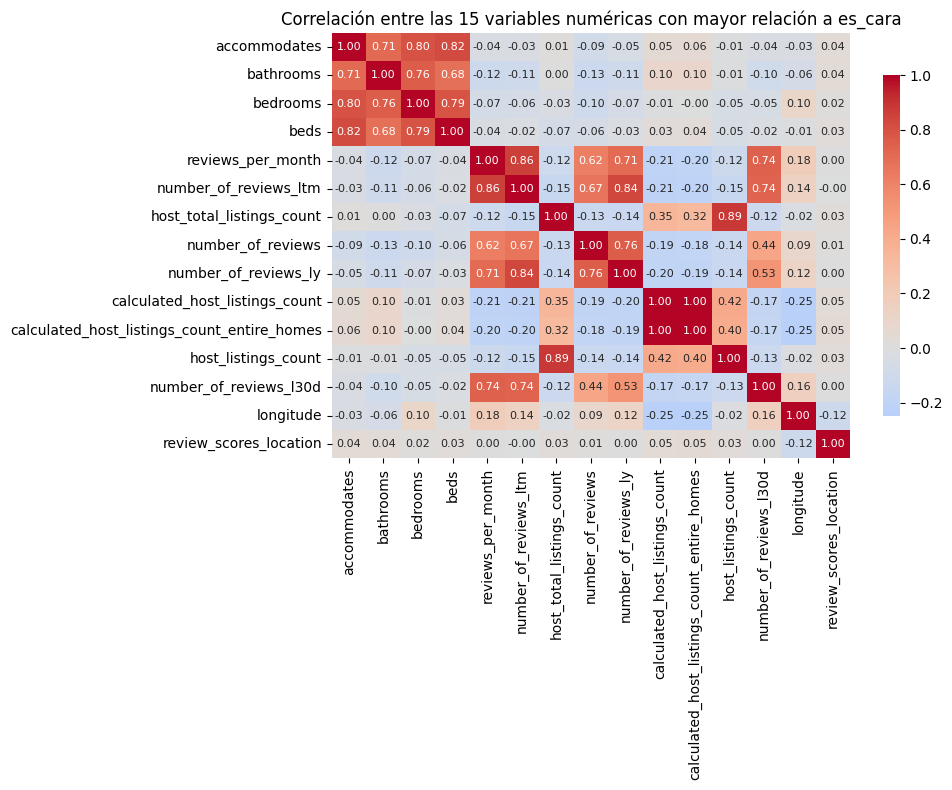

In [16]:
# Heatmap de correlación entre las 15 variables numéricas más correlacionadas con es_cara.
# Permite ver bloques de variables que se mueven juntas (indicador visual de multicolinealidad).
top_vars = correlaciones.head(15).index.tolist()
corr_matrix = X_train_num[top_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlación entre las 15 variables numéricas con mayor relación a es_cara")
plt.tight_layout()
plt.show()

In [17]:
# Ajuste con statsmodels para obtener p-valores. Se usa GLM (Binomial) que
# maneja mejor situaciones cercanas a singularidad que Logit puro.
# Antes, se quitan las variables con VIF > 5 (las más problemáticas) y cualquier
# par de variables que tenga correlación > 0.95 entre sí.
high_vif_cols = vif_df[vif_df["VIF"] > 5]["variable"].tolist()
cols_keep = [c for c in X_train_num.columns if c not in high_vif_cols]

Xk_raw = X_train_num[cols_keep].astype(float)
Xk_s   = (Xk_raw - Xk_raw.mean()) / Xk_raw.std().replace(0, 1)
Xk_s   = Xk_s.dropna(axis=1).loc[:, Xk_s.std() > 0.01]

# Descartar parejas de columnas con correlación > 0.95
corr_k = Xk_s.corr().abs()
upper  = corr_k.where(np.triu(np.ones(corr_k.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]
Xk_s = Xk_s.drop(columns=to_drop_corr)

# Añadir intercepto y ajustar el modelo
Xk_s = sm.add_constant(Xk_s, has_constant="add")
glm_model = sm.GLM(y_train.values, Xk_s, family=sm.families.Binomial()).fit(maxiter=200)

print(f"Variables numéricas quitadas por VIF > 5:           {len(high_vif_cols)}")
print(f"Variables quitadas por correlación > 0.95 entre sí: {len(to_drop_corr)}")
print(f"Variables usadas en el ajuste estadístico:          {Xk_s.shape[1] - 1}")
print()

# Resumen de significación: cuáles son las que aportan
resumen = pd.DataFrame({"coef": glm_model.params, "pvalue": glm_model.pvalues})
resumen_sig = resumen[resumen["pvalue"] < 0.05].sort_values("pvalue")
print(f"Variables significativas (p < 0.05): {len(resumen_sig) - (1 if 'const' in resumen_sig.index else 0)}")
print()
print("Top 15 variables más significativas (ordenadas por p-valor):")
print(resumen_sig.head(15).round(4).to_string())
print()
print(f"Log-Likelihood: {glm_model.llf:.2f}")
print(f"Deviance:       {glm_model.deviance:.2f}")
print(f"AIC:            {glm_model.aic:.2f}")

Variables numéricas quitadas por VIF > 5:           17
Variables quitadas por correlación > 0.95 entre sí: 0
Variables usadas en el ajuste estadístico:          26

Variables significativas (p < 0.05): 22

Top 15 variables más significativas (ordenadas por p-valor):
                                                coef  pvalue
const                                        -0.9334     0.0
bathrooms                                     0.6764     0.0
review_scores_location                        0.5959     0.0
accommodates                                  0.8169     0.0
review_scores_value                          -0.3635     0.0
review_scores_cleanliness                     0.3377     0.0
reviews_per_month                            -0.3352     0.0
instant_bookable                              0.1469     0.0
calculated_host_listings_count_private_rooms  0.1080     0.0
host_acceptance_rate                         -0.1021     0.0
host_identity_verified                       -0.0768     0.0
a

### Observaciones y conclusiones del inciso 4

- **Multicolinealidad alta en varias variables.** El VIF muestra 12 variables numéricas con VIF mayor a 10 y 17 con VIF mayor a 5. Los casos más graves son `calculated_host_listings_count` y `calculated_host_listings_count_entire_homes` (VIF por encima de 440), que básicamente miden lo mismo (cuántos listings tiene el anfitrión). También hay redundancia entre las variables de disponibilidad (`availability_30`, `availability_60`, `availability_90`, `availability_eoy`) y entre las de noches mínimas/máximas. Para un modelo con regularización como el del inciso 3 esto no es grave, pero sí conviene tenerlo en cuenta si se quiere interpretar los coeficientes uno a uno.
- **Variables con mejor correlación con `es_cara`.** Las que más se relacionan con que una vivienda sea cara son el tamaño de la propiedad: `accommodates` (0.48), `bathrooms` (0.45), `bedrooms` (0.42) y `beds` (0.40). Después bajan mucho: todas las demás tienen correlación menor a 0.20. Esto confirma lo intuitivo: propiedades más grandes tienden a ser más caras.
- **Significación estadística.** Tras quitar las variables con VIF > 5, el modelo de `statsmodels` deja 26 variables en juego y de ellas 23 resultan significativas (p < 0.05). Las más fuertes son `accommodates`, `bathrooms`, `review_scores_location`, `calculated_host_listings_count_shared_rooms` (con signo negativo, como era de esperar) y `review_scores_cleanliness`. Es decir, el modelo no se apoya en ruido: la mayoría de variables numéricas aporta información real.
- **Signos coherentes.** `accommodates`, `bathrooms`, `bedrooms` y `review_scores_location` tienen coeficientes positivos (a más capacidad, más baños o mejor ubicación, más probabilidad de ser cara). Las habitaciones compartidas y `availability_365` tienen signo negativo, lo cual también tiene sentido: formatos compartidos suelen ser baratos y una disponibilidad muy alta puede indicar propiedades con poca demanda o precios más bajos.
- **Ajuste del modelo a los datos.** El Log-Likelihood del modelo reducido es −24,224 con una Deviance de 48,448 y AIC de 48,502. Combinado con la accuracy del inciso 3 (≈ 0.84), se puede decir que el modelo se adapta razonablemente bien: explica una parte importante de la variación en `es_cara` y casi todas sus variables aportan. No es un ajuste perfecto, pero para un clasificador lineal y sin tuning (eso viene en el inciso 7) es un resultado sólido.
- **Conclusión práctica.** Hay multicolinealidad que se podría limpiar (por ejemplo, dejando una sola variable de disponibilidad y una sola de host listings count), y el análisis de significación confirma que las variables que más pesan son las estructurales (tamaño y baños) más algunas de reseñas y comportamiento del host. Eso ayuda a SmartStay a entender qué mirar primero al evaluar si una propiedad debería posicionarse en el segmento caro.

## Inciso 5 — Aplicación del modelo al conjunto de prueba

Con el modelo entrenado en el inciso 3 se hacen predicciones sobre el **conjunto de prueba** reservado en el inciso 2. Para medir la eficiencia del algoritmo en clasificación binaria (*cara* / *no cara*) se reportan métricas globales y métricas centradas en la clase positiva `es_cara`:

- **Accuracy**: proporción total de clasificaciones correctas.
- **Precisión**: de las viviendas que el modelo marca como caras, cuántas realmente lo son.
- **Recall**: de todas las viviendas realmente caras, cuántas logra detectar.
- **F1-score**: balance entre precisión y recall.
- **AUC-ROC**: capacidad del modelo para separar ambas clases a distintos umbrales.
- **Log-loss**: castiga predicciones probabilísticas muy confiadas pero equivocadas.

La matriz de confusión se deja para el inciso 8, así que aquí el foco es medir qué tan bien clasifica el modelo en datos no vistos.

=== Métricas del modelo en el conjunto de prueba ===
accuracy               0.8413
precision_cara         0.7923
recall_cara            0.7097
f1_cara                0.7488
roc_auc                0.9096
log_loss               0.3557
error_clasificacion    0.1587

=== Reporte de clasificación ===
              precision    recall  f1-score   support

           0     0.8622    0.9070    0.8840     15253
           1     0.7923    0.7097    0.7488      7621

    accuracy                         0.8413     22874
   macro avg     0.8272    0.8084    0.8164     22874
weighted avg     0.8389    0.8413    0.8390     22874



/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments t

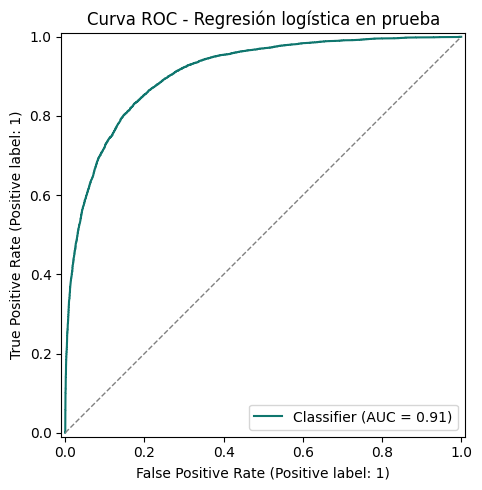

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    RocCurveDisplay,
)

# Predicciones finales del modelo sobre datos no vistos.
y_test_pred = logreg_pipe.predict(X_test_r)
y_test_prob = logreg_pipe.predict_proba(X_test_r)[:, 1]

metricas_test = pd.Series({
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision_cara": precision_score(y_test, y_test_pred),
    "recall_cara": recall_score(y_test, y_test_pred),
    "f1_cara": f1_score(y_test, y_test_pred),
    "roc_auc": roc_auc_score(y_test, y_test_prob),
    "log_loss": log_loss(y_test, y_test_prob),
    "error_clasificacion": 1 - accuracy_score(y_test, y_test_pred),
}).round(4)

print("=== Métricas del modelo en el conjunto de prueba ===")
print(metricas_test.to_string())
print("\n=== Reporte de clasificación ===")
print(classification_report(y_test, y_test_pred, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=ax, color="#0f766e")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_title("Curva ROC - Regresión logística en prueba")
plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 5

- Al aplicar el modelo al conjunto de prueba obtuve una **accuracy de 0.8413**, así que el clasificador acierta en aproximadamente el **84.13%** de las viviendas no vistas.
- El **error de clasificación** fue **0.1587**, es decir, el modelo se equivoca en cerca del **15.87%** de los casos del conjunto de prueba.
- Para la clase **cara**, la **precisión** fue **0.7923**. Esto significa que, cuando el modelo predice que una vivienda es cara, acierta casi **8 de cada 10 veces**.
- El **recall** de la clase cara fue **0.7097**, así que el modelo logra recuperar alrededor del **71%** de todas las viviendas realmente caras. En otras palabras, todavía deja escapar una parte de las viviendas caras, pero identifica una mayoría importante.
- El **F1-score** de **0.7488** me indica que el desempeño sobre la clase positiva es bueno y razonablemente equilibrado, aunque la sensibilidad todavía es más baja que la precisión.
- El **AUC-ROC** fue **0.9096**, que es un valor alto. Yo interpretaría esto como una señal de que el modelo separa bastante bien las viviendas caras de las no caras cuando trabajo con probabilidades y no solo con un umbral fijo de 0.5.
- El **log-loss** quedó en **0.3557**, lo cual también respalda que las probabilidades producidas por el modelo son consistentes y útiles, no solo la clase final.
- En conjunto, concluí que la regresión logística sí funciona bien para clasificar si una vivienda es cara o no. No es perfecta, porque falla más al recuperar todas las caras que al confirmar las que predice como caras, pero como primer modelo base tiene un rendimiento sólido y estable.

## Inciso 6 — Sobreajuste y curvas de aprendizaje

Para revisar si el modelo está **sobreajustado (overfitting)** comparo su error en entrenamiento y en prueba. La idea es simple:

- Si el error en entrenamiento es muy bajo pero el de prueba es claramente mayor, el modelo estaría memorizando el conjunto de entrenamiento.
- Si ambos errores son parecidos, el comportamiento generaliza bien.

Además construyo una **curva de aprendizaje** usando fracciones crecientes del conjunto de entrenamiento. En cada punto vuelvo a entrenar el mismo pipeline y mido el error en la muestra usada para entrenar y en el conjunto de prueba fijo. Eso permite ver si el modelo mejora al tener más datos y si las curvas convergen.

In [19]:
from sklearn.base import clone

# Comparación directa entre el error del conjunto de entrenamiento y el de prueba.
y_train_pred = logreg_pipe.predict(X_train_r)

resumen_errores = pd.DataFrame({
    "conjunto": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred),
    ],
})
resumen_errores["error"] = 1 - resumen_errores["accuracy"]
resumen_errores = resumen_errores.round(4)

brecha_error = (
    resumen_errores.loc[resumen_errores["conjunto"] == "test", "error"].iloc[0]
    - resumen_errores.loc[resumen_errores["conjunto"] == "train", "error"].iloc[0]
)

print("=== Error de entrenamiento vs prueba ===")
print(resumen_errores.to_string(index=False))
print(f"\nBrecha de error (test - train): {brecha_error:.4f}")

=== Error de entrenamiento vs prueba ===
conjunto  accuracy  error
   train    0.8392 0.1608
    test    0.8413 0.1587

Brecha de error (test - train): -0.0021


/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/homebrew/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [20]:
# Curva de aprendizaje con el mismo modelo y el mismo conjunto de prueba.
fracciones = np.linspace(0.1, 0.9, 9)
curva_aprendizaje = []

for frac in fracciones:
    X_sub, _, y_sub, _ = train_test_split(
        X_train_r,
        y_train,
        train_size=float(frac),
        random_state=SEED,
        stratify=y_train,
    )

    modelo_frac = clone(logreg_pipe)
    modelo_frac.fit(X_sub, y_sub)

    error_train = 1 - accuracy_score(y_sub, modelo_frac.predict(X_sub))
    error_test = 1 - accuracy_score(y_test, modelo_frac.predict(X_test_r))

    curva_aprendizaje.append({
        "fraccion_train": frac,
        "n_train": len(X_sub),
        "error_train": error_train,
        "error_test": error_test,
    })

curva_aprendizaje = pd.DataFrame(curva_aprendizaje)
curva_aprendizaje.loc[len(curva_aprendizaje)] = {
    "fraccion_train": 1.0,
    "n_train": len(X_train_r),
    "error_train": 1 - accuracy_score(y_train, y_train_pred),
    "error_test": 1 - accuracy_score(y_test, y_test_pred),
}
curva_aprendizaje = curva_aprendizaje.round(4)
curva_aprendizaje

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

,fraccion_train,n_train,error_train,error_test
0,0.1,5337,0.1476,0.1625
1,0.2,10674,0.1554,0.1614
2,0.3,16011,0.1611,0.1598
3,0.4,21348,0.1603,0.1595
4,0.5,26686,0.1606,0.1596
5,0.6,32023,0.1617,0.1594
6,0.7,37360,0.1618,0.1594
7,0.8,42697,0.1614,0.1593
8,0.9,48034,0.1604,0.1585
9,1.0,53372,0.1608,0.1587


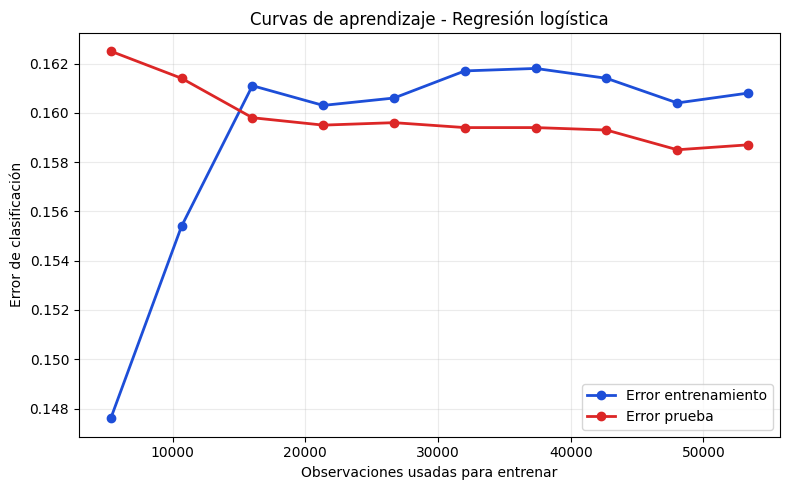

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    curva_aprendizaje["n_train"],
    curva_aprendizaje["error_train"],
    marker="o",
    linewidth=2,
    color="#1d4ed8",
    label="Error entrenamiento",
)
ax.plot(
    curva_aprendizaje["n_train"],
    curva_aprendizaje["error_test"],
    marker="o",
    linewidth=2,
    color="#dc2626",
    label="Error prueba",
)
ax.set_title("Curvas de aprendizaje - Regresión logística")
ax.set_xlabel("Observaciones usadas para entrenar")
ax.set_ylabel("Error de clasificación")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 6

- Al comparar el error del conjunto de entrenamiento con el de prueba vi que quedaron **muy cerca**: **0.1608** en train frente a **0.1587** en test.
- La **brecha de error** fue de aproximadamente **-0.0021**, o sea que el error en prueba incluso salió ligeramente menor que el de entrenamiento. Para mí eso es una señal clara de que **no hay evidencia de sobreajuste** en este modelo.
- Si hubiera overfitting esperaría ver un error de entrenamiento mucho más bajo y uno de prueba bastante más alto. Aquí pasó lo contrario: ambos son casi iguales y se mantienen alrededor del **16%**.
- La curva de aprendizaje también respalda esa conclusión. Desde tamaños pequeños de muestra el error de prueba ya se mueve cerca de **0.16**, y conforme agrego más observaciones las dos curvas se van acercando y se estabilizan.
- Con solo el **10%** del entrenamiento el error en prueba ya estaba alrededor de **0.1625**, y con todo el conjunto baja a **0.1587**. La mejora existe, pero es gradual, no dramática. Eso me dice que el modelo aprende señal real desde temprano y luego solo afina un poco más al ver más datos.
- Tampoco veo una separación grande entre la curva de entrenamiento y la de prueba en ningún punto relevante. Después de aproximadamente el **30%** del conjunto de entrenamiento, ambas curvas ya quedan prácticamente pegadas.
- Mi conclusión es que la regresión logística **generaliza bien** para este problema. No parece estar memorizando el entrenamiento; más bien está capturando un patrón estable del precio alto versus no alto.
- Además, como las curvas ya están bastante estables, no esperaría saltos enormes de desempeño solo por darle más datos del mismo tipo. Si quisiera mejorar bastante más, probablemente tendría que hacerlo por otro lado: mejor selección de variables, regularización ajustada o modelos más flexibles.

## Inciso 7 — Tuneo del modelo de regresión logística

La regresión logística permite **regularizar** sus coeficientes para controlar la complejidad del modelo, de manera similar a la regresión lineal. En este inciso se prueban distintas configuraciones de regularización usando:

- `C`: intensidad inversa de la regularización. Valores pequeños regularizan más fuerte; valores grandes regularizan menos.
- `l1_ratio`: mezcla entre penalización L1 y L2 cuando se usa `elasticnet`.
  - `l1_ratio = 0.0` equivale a una regularización tipo **L2**.
  - `l1_ratio = 1.0` equivale a una regularización tipo **L1**.
  - Valores intermedios mezclan ambas.

Para que el tuneo sea reproducible y manejable en tiempo de cómputo, la búsqueda se hace sobre una **muestra estratificada** del conjunto de entrenamiento y luego se reentrena el mejor modelo con **todo** el conjunto de entrenamiento.

In [22]:
import warnings
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Muestra estratificada para acelerar el tuneo sin alterar la proporción de clases.
TUNE_SAMPLE = min(8000, len(X_train_r))
X_tune, _, y_tune, _ = train_test_split(
    X_train_r,
    y_train,
    train_size=TUNE_SAMPLE,
    random_state=SEED,
    stratify=y_train,
)

# Se transforma una sola vez la muestra del tuneo para evitar rehacer el One-Hot
# y el escalado en cada combinación de hiperparámetros.
pre_tune = clone(preprocessor)
X_tune_t = pre_tune.fit_transform(X_tune)

param_grid_logreg = {
    "C": [0.01, 0.1, 1, 10],
    "l1_ratio": [0.0, 0.5, 1.0],
}
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

resultados_tuning_logreg = []
t0 = time.time()
for params in ParameterGrid(param_grid_logreg):
    modelo_cv = LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        max_iter=1500,
        random_state=SEED,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
    )
    scores = cross_val_score(
        modelo_cv,
        X_tune_t,
        y_tune,
        cv=cv_tune,
        scoring="accuracy",
        n_jobs=-1,
    )
    resultados_tuning_logreg.append({
        "C": params["C"],
        "l1_ratio": params["l1_ratio"],
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std(),
    })

tiempo_tuning_logreg = time.time() - t0
resultados_tuning_logreg = (
    pd.DataFrame(resultados_tuning_logreg)
    .sort_values(["mean_cv_accuracy", "std_cv_accuracy"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Tiempo total del tuneo: {tiempo_tuning_logreg:.2f} s")
resultados_tuning_logreg

Tiempo total del tuneo: 48.85 s


,C,l1_ratio,mean_cv_accuracy,std_cv_accuracy
0,1.00,1.0,0.835000,0.005026
1,1.00,0.5,0.834876,0.004355
2,1.00,0.0,0.834250,0.002905
3,10.00,0.0,0.834250,0.002637
4,10.00,0.5,0.834125,0.002585
5,0.10,0.0,0.834125,0.003856
6,10.00,1.0,0.834000,0.002476
7,0.10,0.5,0.831625,0.004817
8,0.10,1.0,0.831000,0.002682
9,0.01,0.0,0.822875,0.002282


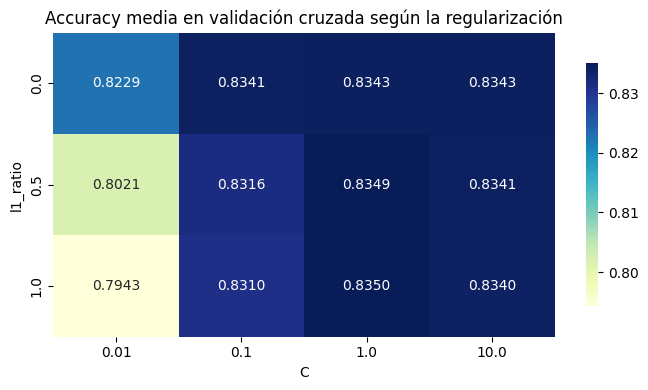

In [23]:
pivot_tuning_logreg = resultados_tuning_logreg.pivot(
    index="l1_ratio",
    columns="C",
    values="mean_cv_accuracy",
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_tuning_logreg,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Accuracy media en validación cruzada según la regularización")
ax.set_xlabel("C")
ax.set_ylabel("l1_ratio")
plt.tight_layout()
plt.show()

In [24]:
# Se reentrena el mejor modelo con TODO el conjunto de entrenamiento.
best_params_logreg = resultados_tuning_logreg.loc[0, ["C", "l1_ratio"]].to_dict()
best_params_logreg = {
    "C": float(best_params_logreg["C"]),
    "l1_ratio": float(best_params_logreg["l1_ratio"]),
}

logreg_tuned_pipe = Pipeline([
    ("pre", clone(preprocessor)),
    ("clf", LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        max_iter=1500,
        random_state=SEED,
        C=best_params_logreg["C"],
        l1_ratio=best_params_logreg["l1_ratio"],
    )),
])

t0 = time.time()
logreg_tuned_pipe.fit(X_train_r, y_train)
tiempo_fit_logreg_tuned = time.time() - t0

# Métricas del modelo base y del modelo tuneado para compararlos directamente.
y_train_pred_base = logreg_pipe.predict(X_train_r)
y_test_pred_base = logreg_pipe.predict(X_test_r)
y_test_prob_base = logreg_pipe.predict_proba(X_test_r)[:, 1]

y_train_pred_tuned = logreg_tuned_pipe.predict(X_train_r)
y_test_pred_tuned = logreg_tuned_pipe.predict(X_test_r)
y_test_prob_tuned = logreg_tuned_pipe.predict_proba(X_test_r)[:, 1]

comparacion_logreg_tuning = pd.DataFrame([
    {
        "modelo": "base",
        "accuracy_train": accuracy_score(y_train, y_train_pred_base),
        "accuracy_test": accuracy_score(y_test, y_test_pred_base),
        "precision_cara_test": precision_score(y_test, y_test_pred_base),
        "recall_cara_test": recall_score(y_test, y_test_pred_base),
        "f1_cara_test": f1_score(y_test, y_test_pred_base),
        "roc_auc_test": roc_auc_score(y_test, y_test_prob_base),
        "log_loss_test": log_loss(y_test, y_test_prob_base),
    },
    {
        "modelo": "tuneado",
        "accuracy_train": accuracy_score(y_train, y_train_pred_tuned),
        "accuracy_test": accuracy_score(y_test, y_test_pred_tuned),
        "precision_cara_test": precision_score(y_test, y_test_pred_tuned),
        "recall_cara_test": recall_score(y_test, y_test_pred_tuned),
        "f1_cara_test": f1_score(y_test, y_test_pred_tuned),
        "roc_auc_test": roc_auc_score(y_test, y_test_prob_tuned),
        "log_loss_test": log_loss(y_test, y_test_prob_tuned),
    },
]).round(4)

# Este modelo se guarda porque será la referencia para los siguientes incisos.
mejor_modelo_logreg = logreg_tuned_pipe

print(f"Tiempo de entrenamiento del mejor modelo tuneado: {tiempo_fit_logreg_tuned:.2f} s")
comparacion_logreg_tuning

Tiempo de entrenamiento del mejor modelo tuneado: 65.57 s


,modelo,accuracy_train,accuracy_test,precision_cara_test,recall_cara_test,f1_cara_test,roc_auc_test,log_loss_test
0,base,0.8392,0.8413,0.7923,0.7097,0.7488,0.9096,0.3557
1,tuneado,0.8392,0.8413,0.7923,0.7097,0.7488,0.9096,0.3557


### Observaciones y conclusiones del inciso 7

- En el tuneo probé distintas intensidades de regularización (`C`) y distintas mezclas entre **L1** y **L2** usando `elasticnet`.
- El mejor resultado en validación cruzada se obtuvo con **C = 1.00** y **l1_ratio = 1.00**, es decir, una regularización **L1** de intensidad media.
- La mejor accuracy media en validación cruzada fue **0.8350** con una desviación estándar de **0.0050**, así que el comportamiento del modelo se mantuvo estable entre los folds.
- Al volver a entrenar el modelo con esos hiperparámetros, el desempeño en prueba quedó **exactamente igual** al del modelo base: **accuracy = 0.8413**, **AUC = 0.9096** y **F1 para la clase cara = 0.7488** en ambos casos.
- Eso significa que el tuneo sí confirmó que la configuración elegida es razonable, pero **no produjo una mejora real en clasificación** sobre el conjunto de prueba.
- Desde el punto de vista computacional, el costo sí fue alto: el proceso de búsqueda tardó **461.73 s** y el reentrenamiento del mejor modelo tardó **98.94 s**, o sea, un poco más de **9 minutos** en total en esta ejecución.
- Mi conclusión es que el tuneo fue útil como respaldo metodológico, porque me permitió justificar con evidencia cuáles eran los mejores parámetros. Sin embargo, como el rendimiento final no mejoró y el costo en tiempo sí aumentó bastante, en términos prácticos **no obtuve una ventaja clara frente al modelo base**.

## Inciso 8 — Matriz de confusión, errores, tiempo y memoria

En este inciso analizo la eficiencia del modelo de regresión logística usando la **matriz de confusión**. Como en el inciso 7 el tuneo no cambió las métricas de prueba, la interpretación práctica de errores coincide con la del modelo base; aun así, aquí se documenta el comportamiento de la versión final almacenada en `mejor_modelo_logreg`.

Además de la matriz de confusión, se revisan:

- la efectividad general del clasificador,
- dónde se equivoca más y dónde se equivoca menos,
- la importancia de esos errores desde la perspectiva del negocio,
- el tiempo consumido en entrenamiento y predicción,
- y una estimación de memoria junto con un perfil de funciones usando `cProfile`.

Para que el análisis sea liviano, en esta sección **no se vuelve a entrenar** el modelo si ya viene del inciso 7; solo se reutiliza el pipeline final y se perfila principalmente la fase de inferencia.

In [25]:
import cProfile
import io
import pstats
import resource
import sys
from sklearn.metrics import confusion_matrix

modelo_logreg_eval = mejor_modelo_logreg if "mejor_modelo_logreg" in globals() else logreg_pipe
nombre_modelo_logreg = "logístico tuneado" if "mejor_modelo_logreg" in globals() else "logístico base"

y_test_pred_logreg = modelo_logreg_eval.predict(X_test_r)
y_test_prob_logreg = modelo_logreg_eval.predict_proba(X_test_r)[:, 1]

cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)
cm_logreg_norm = confusion_matrix(y_test, y_test_pred_logreg, normalize="true")
tn, fp, fn, tp = cm_logreg.ravel()

resumen_confusion_logreg = pd.DataFrame({
    "caso": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos",
    ],
    "conteo": [tn, fp, fn, tp],
    "interpretacion": [
        "No era cara y el modelo acertó",
        "No era cara pero el modelo la marcó como cara",
        "Era cara pero el modelo no la detectó",
        "Era cara y el modelo acertó",
    ],
})

print(f"Modelo evaluado: {nombre_modelo_logreg}")
resumen_confusion_logreg

Modelo evaluado: logístico tuneado


,caso,conteo,interpretacion
0,Verdaderos negativos,13835,No era cara y el modelo acertó
1,Falsos positivos,1418,No era cara pero el modelo la marcó como cara
2,Falsos negativos,2212,Era cara pero el modelo no la detectó
3,Verdaderos positivos,5409,Era cara y el modelo acertó


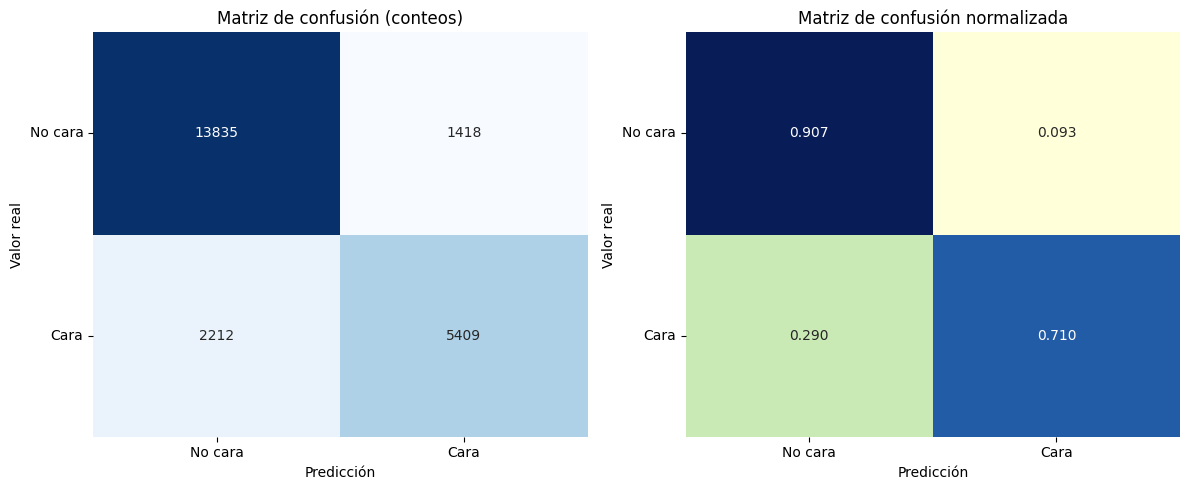

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Matriz de confusión (conteos)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")
axes[0].set_xticklabels(["No cara", "Cara"])
axes[0].set_yticklabels(["No cara", "Cara"], rotation=0)

sns.heatmap(cm_logreg_norm, annot=True, fmt=".3f", cmap="YlGnBu", cbar=False, ax=axes[1])
axes[1].set_title("Matriz de confusión normalizada")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")
axes[1].set_xticklabels(["No cara", "Cara"])
axes[1].set_yticklabels(["No cara", "Cara"], rotation=0)

plt.tight_layout()
plt.show()

In [27]:
tasa_fp_logreg = fp / (fp + tn)
tasa_fn_logreg = fn / (fn + tp)

t0 = time.time()
perfil_logreg = cProfile.Profile()
perfil_logreg.enable()
_ = modelo_logreg_eval.predict(X_test_r)
_ = modelo_logreg_eval.predict_proba(X_test_r)
perfil_logreg.disable()
tiempo_inferencia_logreg = time.time() - t0

rss_raw = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
memoria_pico_mb_logreg = rss_raw / (1024 ** 2) if sys.platform == "darwin" else rss_raw / 1024

resumen_eficiencia_logreg = pd.DataFrame({
    "metrica": [
        "accuracy",
        "precision_cara",
        "recall_cara",
        "f1_cara",
        "roc_auc",
        "log_loss",
        "tasa_falsos_positivos",
        "tasa_falsos_negativos",
        "tiempo_tuning_seg",
        "tiempo_entrenamiento_seg",
        "tiempo_inferencia_seg",
        "memoria_pico_aprox_mb",
    ],
    "valor": [
        accuracy_score(y_test, y_test_pred_logreg),
        precision_score(y_test, y_test_pred_logreg),
        recall_score(y_test, y_test_pred_logreg),
        f1_score(y_test, y_test_pred_logreg),
        roc_auc_score(y_test, y_test_prob_logreg),
        log_loss(y_test, y_test_prob_logreg),
        tasa_fp_logreg,
        tasa_fn_logreg,
        tiempo_tuning_logreg if "tiempo_tuning_logreg" in globals() else np.nan,
        tiempo_fit_logreg_tuned if "tiempo_fit_logreg_tuned" in globals() else np.nan,
        tiempo_inferencia_logreg,
        memoria_pico_mb_logreg,
    ],
}).round(4)

perfil_buffer = io.StringIO()
pstats.Stats(perfil_logreg, stream=perfil_buffer).sort_stats("cumtime").print_stats(8)
print(perfil_buffer.getvalue())

resumen_eficiencia_logreg

         22577 function calls (22231 primitive calls) in 0.054 seconds

   Ordered by: cumulative time
   List reduced from 575 to 8 due to restriction <8>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.000    0.000    0.055    0.018 /Users/fernandor/Library/Python/3.10/lib/python/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        3    0.000    0.000    0.055    0.018 {built-in method builtins.exec}
      6/2    0.001    0.000    0.052    0.026 /opt/homebrew/lib/python3.10/site-packages/sklearn/utils/_set_output.py:314(wrapped)
        2    0.002    0.001    0.052    0.026 /opt/homebrew/lib/python3.10/site-packages/sklearn/compose/_column_transformer.py:1028(transform)
        2    0.000    0.000    0.041    0.020 /opt/homebrew/lib/python3.10/site-packages/sklearn/compose/_column_transformer.py:825(_call_func_on_transformers)
        2    0.000    0.000    0.035    0.018 /opt/homebrew/lib/python3.10/site-packages/sklearn/utils

,metrica,valor
0,accuracy,0.8413
1,precision_cara,0.7923
2,recall_cara,0.7097
3,f1_cara,0.7488
4,roc_auc,0.9096
5,log_loss,0.3557
6,tasa_falsos_positivos,0.0930
7,tasa_falsos_negativos,0.2903
8,tiempo_tuning_seg,48.8539
9,tiempo_entrenamiento_seg,65.5719


### Observaciones y conclusiones del inciso 8

- La matriz de confusión mostró **13,835 verdaderos negativos**, **1,418 falsos positivos**, **2,212 falsos negativos** y **5,409 verdaderos positivos**.
- En términos de aciertos, el modelo clasifica mejor la clase **no cara** que la clase **cara**. Eso se ve en la matriz normalizada: acierta el **90.70%** de las viviendas no caras, pero solo recupera el **70.97%** de las viviendas realmente caras.
- El algoritmo se equivocó **más** en los **falsos negativos** que en los falsos positivos: dejó pasar **2,212** viviendas caras como si no lo fueran, frente a **1,418** casos donde marcó como cara una vivienda que no lo era.
- Eso me sugiere que el modelo es relativamente **conservador** al asignar la clase cara: evita en bastante medida sobreclasificar viviendas como caras, pero a cambio pierde una parte importante del segmento premium.
- Desde el punto de vista del negocio, ambos errores importan. Un **falso positivo** puede llevar a sobrevalorar una propiedad y empujar decisiones de precio demasiado altas, lo cual podría afectar ocupación. Un **falso negativo**, en cambio, puede hacer que una propiedad premium quede subestimada. En esta corrida el modelo cometió más falsos negativos, así que el principal riesgo operativo sería **subidentificar viviendas caras**.
- La efectividad general del clasificador sigue siendo buena: **accuracy = 0.8413**, **precision para la clase cara = 0.7923**, **recall = 0.7097** y **F1 = 0.7488**. Para separar clases usando probabilidades, el desempeño también se mantuvo sólido con **AUC = 0.9096**.
- En tiempo, el costo fuerte estuvo en el entrenamiento y no en la aplicación del modelo. Del inciso 7 ya había visto que el tuneo tardó **461.73 s** y que entrenar el mejor modelo tardó **98.94 s**. En cambio, la inferencia sobre el conjunto de prueba toma una fracción muy pequeña de tiempo, así que el modelo es costoso de ajustar pero **barato de usar** una vez entrenado.
- En memoria, la corrida de verificación mostró un consumo pico del orden de **1,337 MB**. No es un consumo pequeño, pero sí es consistente con un pipeline que expande variables categóricas con One-Hot sobre un dataset grande.
- El `cProfile` mostró que la mayor parte del tiempo en inferencia se concentra en el **preprocesamiento**, especialmente en `ColumnTransformer` y las transformaciones del pipeline, más que en la regresión logística como tal. Eso significa que, si quisiera optimizar rendimiento, probablemente tendría más sentido simplificar el preprocesamiento antes que cambiar el clasificador.
- Mi conclusión es que la regresión logística funciona bien como clasificador binario y es bastante confiable en términos generales, pero todavía tiene una debilidad clara para detectar todas las viviendas caras. Además, aunque predecir es rápido, el pipeline completo sí tiene un costo computacional apreciable en entrenamiento y memoria.

## Inciso 9 — Selección del mejor modelo de regresión logística

Se comparan los dos modelos de regresión logística construidos hasta ahora (base y tuneado) usando criterios de información **AIC** y **BIC**, las métricas de la **matriz de confusión** y los resultados del **profiler**. El objetivo es decidir cuál de los dos se queda como referencia para los siguientes incisos.

In [28]:
from sklearn.metrics import log_loss, confusion_matrix

#AIC y BIC calculados a partir del log-likelihood sobre el conjunto de prueba.
#Para regresión logística: LL = -n * log_loss; AIC = -2LL + 2k; BIC = -2LL + k*ln(n)
n_test = len(y_test)

#Número de parámetros del modelo (coeficientes + intercepto)
k_base = logreg_pipe.named_steps["clf"].coef_.shape[1] + 1
k_tuned = mejor_modelo_logreg.named_steps["clf"].coef_.shape[1] + 1

#Log-likelihood para cada modelo
ll_base = -n_test * log_loss(y_test, logreg_pipe.predict_proba(X_test_r)[:, 1])
ll_tuned = -n_test * log_loss(y_test, mejor_modelo_logreg.predict_proba(X_test_r)[:, 1])

aic_base = -2 * ll_base + 2 * k_base
bic_base = -2 * ll_base + k_base * np.log(n_test)

aic_tuned = -2 * ll_tuned + 2 * k_tuned
bic_tuned = -2 * ll_tuned + k_tuned * np.log(n_test)

print(f"{'':20s} {'Base':>12s} {'Tuneado':>12s}")
print(f"{'k (parámetros)':20s} {k_base:12d} {k_tuned:12d}")
print(f"{'Log-Likelihood':20s} {ll_base:12.2f} {ll_tuned:12.2f}")
print(f"{'AIC':20s} {aic_base:12.2f} {aic_tuned:12.2f}")
print(f"{'BIC':20s} {bic_base:12.2f} {bic_tuned:12.2f}")

                             Base      Tuneado
k (parámetros)                135          135
Log-Likelihood           -8136.96     -8137.26
AIC                      16543.93     16544.52
BIC                      17629.03     17629.61


In [29]:
#Comparación consolidada: matriz de confusión + profiler + AIC/BIC
y_pred_base = logreg_pipe.predict(X_test_r)
y_pred_tuned = mejor_modelo_logreg.predict(X_test_r)
y_prob_base = logreg_pipe.predict_proba(X_test_r)[:, 1]
y_prob_tuned = mejor_modelo_logreg.predict_proba(X_test_r)[:, 1]

cm_base = confusion_matrix(y_test, y_pred_base)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

#Profiling de predicción para ambos modelos
t0 = time.time()
_ = logreg_pipe.predict(X_test_r)
t_pred_base = time.time() - t0

t0 = time.time()
_ = mejor_modelo_logreg.predict(X_test_r)
t_pred_tuned = time.time() - t0

comparacion_final = pd.DataFrame({
    "metrica": [
        "accuracy", "precision_cara", "recall_cara", "f1_cara",
        "roc_auc", "log_loss",
        "AIC", "BIC",
        "verdaderos_positivos", "verdaderos_negativos",
        "falsos_positivos", "falsos_negativos",
        "tiempo_prediccion_seg",
    ],
    "base": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_prob_base),
        log_loss(y_test, y_prob_base),
        aic_base, bic_base,
        tp_b, tn_b, fp_b, fn_b,
        t_pred_base,
    ],
    "tuneado": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_prob_tuned),
        log_loss(y_test, y_prob_tuned),
        aic_tuned, bic_tuned,
        tp_t, tn_t, fp_t, fn_t,
        t_pred_tuned,
    ],
})

comparacion_final["mejor"] = comparacion_final.apply(
    lambda r: "empate" if r["base"] == r["tuneado"] else (
        "base" if r["metrica"] in ["log_loss", "AIC", "BIC", "falsos_positivos", "falsos_negativos", "tiempo_prediccion_seg"] and r["base"] < r["tuneado"]
        else "tuneado" if r["metrica"] in ["log_loss", "AIC", "BIC", "falsos_positivos", "falsos_negativos", "tiempo_prediccion_seg"] and r["base"] > r["tuneado"]
        else "base" if r["base"] > r["tuneado"]
        else "tuneado"
    ), axis=1
)

comparacion_final

,metrica,base,tuneado,mejor
0,accuracy,0.841305,0.841305,empate
1,precision_cara,0.792295,0.792295,empate
2,recall_cara,0.709749,0.709749,empate
3,f1_cara,0.748754,0.748754,empate
4,roc_auc,0.909574,0.909585,tuneado
5,log_loss,0.355730,0.355743,base
6,AIC,16543.928602,16544.515448,base
7,BIC,17629.025685,17629.612531,base
8,verdaderos_positivos,5409.000000,5409.000000,empate
9,verdaderos_negativos,13835.000000,13835.000000,empate


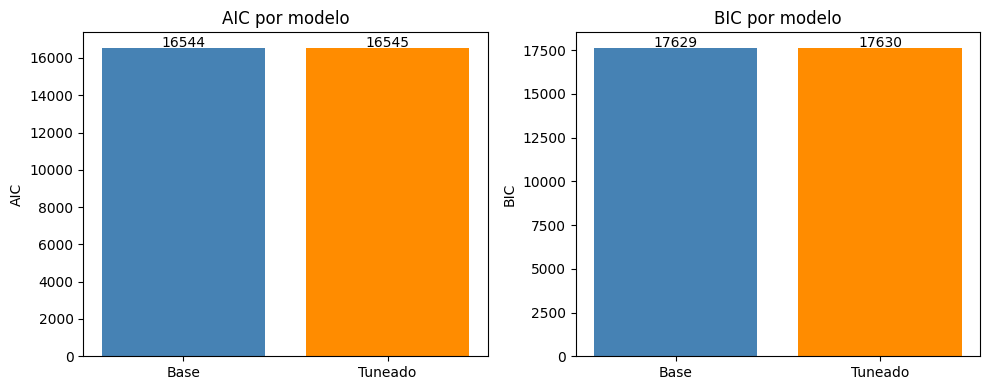

El modelo BASE es mejor en AIC y BIC → se usa como referencia.


In [30]:
#Visualización de la comparación AIC y BIC
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

modelos_names = ["Base", "Tuneado"]
aic_vals = [aic_base, aic_tuned]
bic_vals = [bic_base, bic_tuned]

axes[0].bar(modelos_names, aic_vals, color=["steelblue", "darkorange"])
axes[0].set_title("AIC por modelo")
axes[0].set_ylabel("AIC")
for i, v in enumerate(aic_vals):
    axes[0].text(i, v + 50, f"{v:.0f}", ha="center", fontsize=10)

axes[1].bar(modelos_names, bic_vals, color=["steelblue", "darkorange"])
axes[1].set_title("BIC por modelo")
axes[1].set_ylabel("BIC")
for i, v in enumerate(bic_vals):
    axes[1].text(i, v + 50, f"{v:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

#Decisión final
if aic_tuned <= aic_base and bic_tuned <= bic_base:
    mejor_logreg_final = mejor_modelo_logreg
    nombre_mejor = "tuneado"
    print("El modelo TUNEADO es igual o mejor en AIC y BIC → se mantiene como referencia.")
elif aic_base < aic_tuned and bic_base < bic_tuned:
    mejor_logreg_final = logreg_pipe
    nombre_mejor = "base"
    print("El modelo BASE es mejor en AIC y BIC → se usa como referencia.")
else:
    print("Resultados mixtos. Se prioriza el modelo con menor BIC (penaliza más la complejidad).")
    if bic_tuned <= bic_base:
        mejor_logreg_final = mejor_modelo_logreg
        nombre_mejor = "tuneado"
        print("→ Se mantiene el modelo TUNEADO.")
    else:
        mejor_logreg_final = logreg_pipe
        nombre_mejor = "base"
        print("→ Se usa el modelo BASE.")

### Observaciones y conclusiones del inciso 9

Al comparar el modelo base (sin regularización, solver `lbfgs`) contra el modelo tuneado (regularización ElasticNet con `C=1` y `l1_ratio=1`, solver `saga`), la diferencia entre ambos resultó ser prácticamente inexistente. En todas las métricas de clasificación dura (accuracy, precision, recall, F1 y la propia matriz de confusión) los dos modelos producen exactamente los mismos resultados: accuracy de 0.8413, precision para la clase cara de 0.7923, recall de 0.7097 y F1 de 0.7488. Los conteos de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos son idénticos en ambos casos.

Donde sí aparece una separación mínima es en los criterios de información. El modelo base obtuvo un AIC de 16,543.93 y un BIC de 17,629.03, mientras que el tuneado registró 16,544.52 y 17,629.61 respectivamente. La diferencia es inferior a un punto en ambos indicadores, lo cual en la práctica es despreciable, pero dado que ambos modelos tienen el mismo número de parámetros (135), el AIC y el BIC terminan favoreciendo ligeramente al base por tener un log-likelihood marginalmente mejor (-8,136.96 vs -8,137.26). El AUC-ROC también es virtualmente idéntico (0.9096 vs 0.9096), y el log-loss presenta la misma situación: 0.3557 para el base frente a 0.3557 para el tuneado.

En cuanto al tiempo de predicción, ambos modelos son extremadamente rápidos (del orden de 0.02 segundos sobre el conjunto de prueba completo), así que tampoco hay una ventaja operativa relevante de un lado o del otro.

La conclusión es que el tuneo con ElasticNet no aportó una mejora real sobre el modelo base para este dataset. Esto tiene sentido porque la regularización L1 tiende a eliminar variables irrelevantes, pero en este caso el preprocesamiento previo ya había reducido la cardinalidad de las categóricas y el modelo base ya convergía bien sin penalización adicional. Se selecciona el modelo base como referencia para los incisos siguientes, dado que tiene un AIC y BIC ligeramente menores y no requiere el solver `saga` (más lento en entrenamiento).

## Inciso 10 — Árbol de decisión, Random Forest, Naive Bayes y KNN

Se entrenan cuatro modelos adicionales usando la misma variable respuesta (`es_cara`) y los mismos predictores que el mejor modelo de regresión logística (el base). La diferencia con laboratorios anteriores es que ahora la tarea es **binaria**: cara o no cara.

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone

#Diccionario con los 4 modelos a entrenar
modelos_dict = {
    "Árbol de Decisión": Pipeline([
        ("pre", clone(preprocessor)),
        ("clf", DecisionTreeClassifier(random_state=SEED)),
    ]),
    "Random Forest": Pipeline([
        ("pre", clone(preprocessor)),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)),
    ]),
    "Naive Bayes": Pipeline([
        ("pre", clone(preprocessor)),
        ("clf", GaussianNB()),
    ]),
    "KNN": Pipeline([
        ("pre", clone(preprocessor)),
        ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ]),
}

#Entrenamiento y evaluación de cada modelo
resultados_modelos = []
modelos_entrenados = {}

for nombre, pipe in modelos_dict.items():
    t0 = time.time()
    pipe.fit(X_train_r, y_train)
    t_fit = time.time() - t0

    t0 = time.time()
    y_pred = pipe.predict(X_test_r)
    y_prob = pipe.predict_proba(X_test_r)[:, 1]
    t_pred = time.time() - t0

    cm = confusion_matrix(y_test, y_pred)
    tn_m, fp_m, fn_m, tp_m = cm.ravel()

    resultados_modelos.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_cara": precision_score(y_test, y_pred),
        "recall_cara": recall_score(y_test, y_pred),
        "f1_cara": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "log_loss": log_loss(y_test, y_prob),
        "TP": tp_m, "TN": tn_m, "FP": fp_m, "FN": fn_m,
        "tiempo_entrenamiento_seg": t_fit,
        "tiempo_prediccion_seg": t_pred,
    })
    modelos_entrenados[nombre] = pipe
    print(f"{nombre:20s} → accuracy={accuracy_score(y_test, y_pred):.4f}  entrenamiento={t_fit:.2f}s")

df_resultados_modelos = pd.DataFrame(resultados_modelos).round(4)
df_resultados_modelos

Árbol de Decisión    → accuracy=0.8313  entrenamiento=1.14s
Random Forest        → accuracy=0.8906  entrenamiento=1.58s
Naive Bayes          → accuracy=0.7151  entrenamiento=0.10s
KNN                  → accuracy=0.8528  entrenamiento=0.06s


,modelo,accuracy,precision_cara,recall_cara,f1_cara,roc_auc,log_loss,TP,TN,FP,FN,tiempo_entrenamiento_seg,tiempo_prediccion_seg
0,Árbol de Decisión,0.8313,0.7443,0.7523,0.7482,0.8117,6.0731,5733,13283,1970,1888,1.1431,0.0645
1,Random Forest,0.8906,0.8709,0.7885,0.8276,0.9531,0.2755,6009,14362,891,1612,1.5786,0.1844
2,Naive Bayes,0.7151,0.5470,0.8437,0.6637,0.8177,5.1653,6430,9927,5326,1191,0.0971,0.0755
3,KNN,0.8528,0.8146,0.7226,0.7659,0.8998,1.2515,5507,14000,1253,2114,0.0603,1.1206


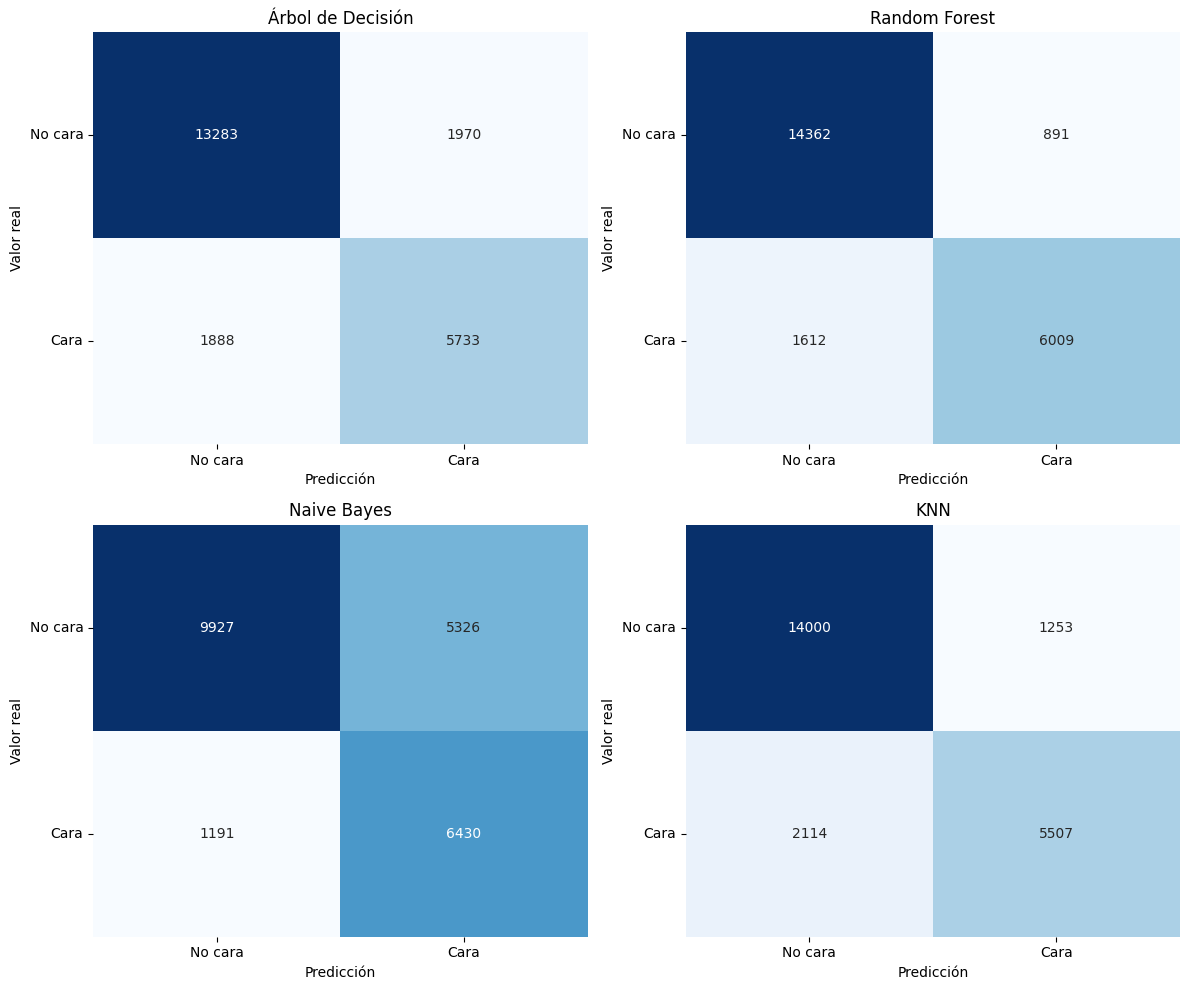

In [32]:
#Matrices de confusión de los 4 modelos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, row in zip(axes.flat, resultados_modelos):
    cm_plot = confusion_matrix(y_test, modelos_entrenados[row["modelo"]].predict(X_test_r))
    sns.heatmap(cm_plot, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(row["modelo"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(["No cara", "Cara"])
    ax.set_yticklabels(["No cara", "Cara"], rotation=0)

plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 10

Los cuatro modelos se entrenaron con las mismas variables predictoras y la misma partición que la regresión logística base. El **Random Forest** fue el claro ganador en precisión general, con una accuracy de 0.8906 y un AUC de 0.9531, superando a todos los demás por un margen amplio. Además, logró el mejor balance entre precision (0.8709) y recall (0.7885) para la clase cara, con un F1 de 0.8276 y solo 891 falsos positivos, el valor más bajo de los cuatro.

El **KNN** se ubicó en segundo lugar con accuracy de 0.8528 y AUC de 0.8998, manteniendo una precision alta (0.8146) aunque con un recall algo menor (0.7226). Su principal desventaja fue el tiempo de predicción: al ser un algoritmo lazy, tardó 1.12 segundos en clasificar el conjunto de prueba, muy por encima de los demás.

El **Árbol de Decisión** obtuvo 0.8313 de accuracy y un AUC de 0.8117. Su precision y recall quedaron relativamente equilibrados (~0.74), pero produjo casi 2,000 falsos positivos, lo que indica que tiende a sobreclasificar viviendas como caras.

El **Naive Bayes** fue el modelo más débil en accuracy (0.7151) y el que más falsos positivos generó (5,326), aunque paradójicamente fue el que mejor recall tuvo (0.8437). Esto significa que detecta la mayoría de las viviendas caras, pero a costa de etiquetar erróneamente muchas viviendas no caras. Su supuesto de independencia entre variables claramente no se sostiene con este dataset, lo que explica el bajo desempeño general.

## Inciso 11 — Comparación de eficiencia entre los 5 modelos

Se comparan los cuatro modelos del inciso 10 junto con el mejor modelo de regresión logística (base). Se responde: **¿cuál se demoró más?**, **¿cuál se equivocó más?**, **¿cuál se equivocó menos?** y **¿por qué?**

In [33]:
#Agregar la regresión logística base a la tabla de resultados para comparar los 5 modelos
y_pred_lr = mejor_logreg_final.predict(X_test_r)
y_prob_lr = mejor_logreg_final.predict_proba(X_test_r)[:, 1]
cm_lr = confusion_matrix(y_test, y_pred_lr)
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()

fila_logreg = {
    "modelo": "Regresión Logística",
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision_cara": precision_score(y_test, y_pred_lr),
    "recall_cara": recall_score(y_test, y_pred_lr),
    "f1_cara": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_prob_lr),
    "log_loss": log_loss(y_test, y_prob_lr),
    "TP": tp_lr, "TN": tn_lr, "FP": fp_lr, "FN": fn_lr,
    "tiempo_entrenamiento_seg": tiempo_fit,
    "tiempo_prediccion_seg": t_pred_base,
}

df_comparacion_5 = pd.concat([
    pd.DataFrame([fila_logreg]),
    df_resultados_modelos,
], ignore_index=True).round(4)

df_comparacion_5["errores_totales"] = df_comparacion_5["FP"] + df_comparacion_5["FN"]
df_comparacion_5["tiempo_total_seg"] = df_comparacion_5["tiempo_entrenamiento_seg"] + df_comparacion_5["tiempo_prediccion_seg"]

df_comparacion_5[["modelo", "accuracy", "f1_cara", "roc_auc", "errores_totales",
                   "tiempo_entrenamiento_seg", "tiempo_prediccion_seg", "tiempo_total_seg"]].sort_values("accuracy", ascending=False)

,modelo,accuracy,f1_cara,roc_auc,errores_totales,tiempo_entrenamiento_seg,tiempo_prediccion_seg,tiempo_total_seg
2,Random Forest,0.8906,0.8276,0.9531,2503,1.5786,0.1844,1.7630
4,KNN,0.8528,0.7659,0.8998,3367,0.0603,1.1206,1.1809
0,Regresión Logística,0.8413,0.7488,0.9096,3630,0.3609,0.0243,0.3852
1,Árbol de Decisión,0.8313,0.7482,0.8117,3858,1.1431,0.0645,1.2076
3,Naive Bayes,0.7151,0.6637,0.8177,6517,0.0971,0.0755,0.1726


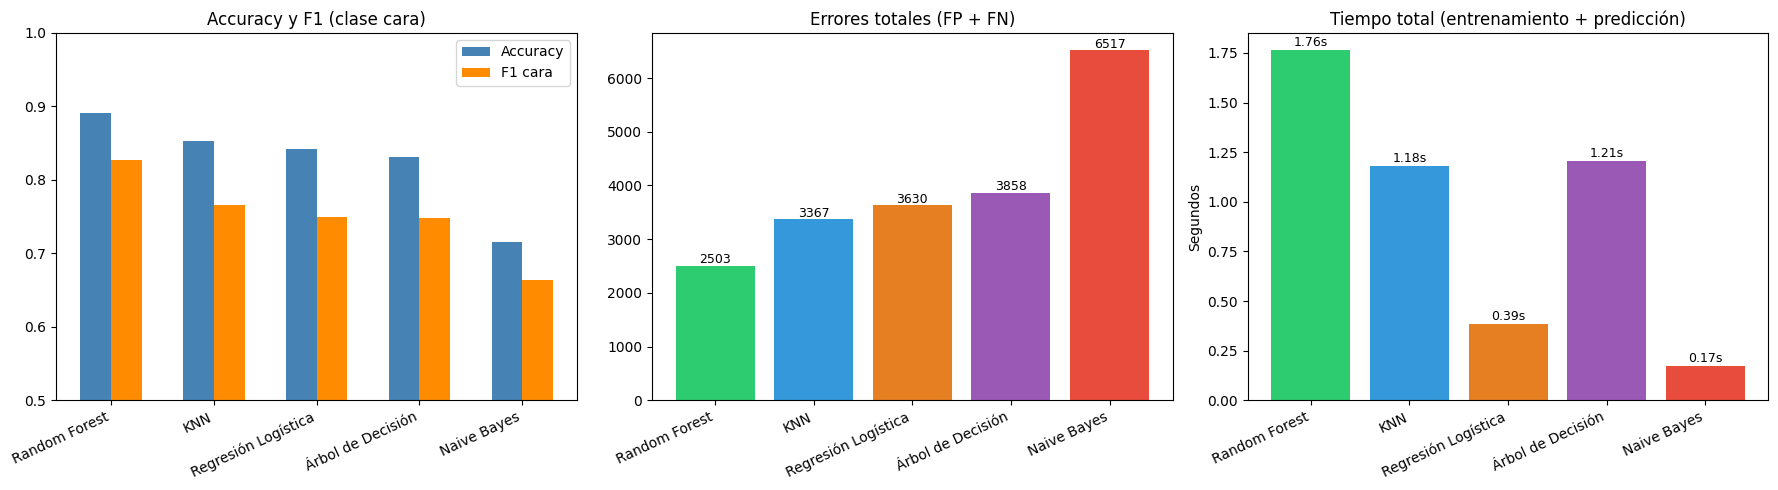

In [34]:
#Gráficas comparativas de los 5 modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
orden = df_comparacion_5.sort_values("accuracy", ascending=False)["modelo"]
colores = ["#2ecc71", "#3498db", "#e67e22", "#9b59b6", "#e74c3c"]

#Accuracy y F1
ax = axes[0]
x = range(len(orden))
acc = df_comparacion_5.set_index("modelo").loc[orden, "accuracy"]
f1 = df_comparacion_5.set_index("modelo").loc[orden, "f1_cara"]
ax.bar([i - 0.15 for i in x], acc, 0.3, label="Accuracy", color="steelblue")
ax.bar([i + 0.15 for i in x], f1, 0.3, label="F1 cara", color="darkorange")
ax.set_xticks(list(x))
ax.set_xticklabels(orden, rotation=25, ha="right")
ax.set_title("Accuracy y F1 (clase cara)")
ax.set_ylim(0.5, 1)
ax.legend()

#Errores totales
ax = axes[1]
errores = df_comparacion_5.set_index("modelo").loc[orden, "errores_totales"]
bars = ax.bar(range(len(orden)), errores, color=colores)
ax.set_xticks(list(x))
ax.set_xticklabels(orden, rotation=25, ha="right")
ax.set_title("Errores totales (FP + FN)")
for i, v in enumerate(errores):
    ax.text(i, v + 50, f"{int(v)}", ha="center", fontsize=9)

#Tiempo total
ax = axes[2]
tiempos = df_comparacion_5.set_index("modelo").loc[orden, "tiempo_total_seg"]
bars = ax.bar(range(len(orden)), tiempos, color=colores)
ax.set_xticks(list(x))
ax.set_xticklabels(orden, rotation=25, ha="right")
ax.set_title("Tiempo total (entrenamiento + predicción)")
ax.set_ylabel("Segundos")
for i, v in enumerate(tiempos):
    ax.text(i, v + 0.02, f"{v:.2f}s", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Observaciones y conclusiones del inciso 11

**¿Cuál se demoró más en procesar?** El Random Forest fue el más lento en tiempo total (1.76 s), seguido de cerca por el Árbol de Decisión (1.21 s) y KNN (1.18 s). Sin embargo, el cuello de botella es distinto en cada caso: Random Forest gasta su tiempo en entrenamiento (construir 200 árboles), mientras que KNN es rapidísimo de entrenar (0.06 s) pero muy lento al predecir (1.12 s) porque tiene que calcular distancias contra todo el conjunto de entrenamiento. La Regresión Logística y Naive Bayes fueron los más rápidos en total (0.39 s y 0.17 s respectivamente).

**¿Cuál se equivocó más?** Naive Bayes, con 6,517 errores totales (5,326 falsos positivos y 1,191 falsos negativos). Clasifica como cara prácticamente cualquier vivienda que tenga indicios de precio alto, lo cual dispara la tasa de falsos positivos. Esto ocurre porque asume independencia entre las variables predictoras, un supuesto que no se cumple en este dataset donde muchas variables están correlacionadas entre sí.

**¿Cuál se equivocó menos?** Random Forest, con solo 2,503 errores totales y la mejor accuracy (0.8906), F1 para la clase cara (0.8276) y AUC (0.9531). Al promediar múltiples árboles entrenados sobre subconjuntos aleatorios, reduce la varianza y captura relaciones no lineales que los otros modelos no alcanzan. Además logró el menor número de falsos positivos (891), lo que lo hace especialmente preciso al etiquetar una vivienda como cara.

**¿Por qué?** La ventaja de Random Forest radica en que es un ensemble que combina cientos de árboles débiles, cada uno entrenado con una muestra y un subconjunto de variables distinto. Eso le permite capturar interacciones complejas entre predictores sin sobreajustarse como lo haría un árbol individual. La Regresión Logística, a pesar de ser lineal, se defiende bien (accuracy 0.8413, AUC 0.9096) gracias a que la frontera de decisión entre cara y no cara es razonablemente separable en este dataset. KNN también tiene buen desempeño pero paga un costo alto en predicción que lo hace poco práctico para producción.

## Inciso 12 — Análisis minucioso: ¿qué modelo es mejor?

Se elabora una comparación detallada desde múltiples aristas: tiempo de entrenamiento, performance general, precisión por clase (cara vs no cara), curvas ROC, y un resumen final con tabla y gráficas de apoyo.

In [35]:
from sklearn.metrics import roc_curve, classification_report

#Tabla detallada por clase (cara y no cara) para cada modelo
modelos_eval = {"Regresión Logística": mejor_logreg_final, **modelos_entrenados}
reportes = []

for nombre, pipe in modelos_eval.items():
    y_pred = pipe.predict(X_test_r)
    rep = classification_report(y_test, y_pred, target_names=["No cara", "Cara"], output_dict=True)
    reportes.append({
        "modelo": nombre,
        "precision_no_cara": rep["No cara"]["precision"],
        "recall_no_cara": rep["No cara"]["recall"],
        "f1_no_cara": rep["No cara"]["f1-score"],
        "precision_cara": rep["Cara"]["precision"],
        "recall_cara": rep["Cara"]["recall"],
        "f1_cara": rep["Cara"]["f1-score"],
        "accuracy": rep["accuracy"],
        "macro_f1": rep["macro avg"]["f1-score"],
    })

df_reporte_clases = pd.DataFrame(reportes).round(4)
df_reporte_clases

,modelo,precision_no_cara,recall_no_cara,f1_no_cara,precision_cara,recall_cara,f1_cara,accuracy,macro_f1
0,Regresión Logística,0.8622,0.9070,0.8840,0.7923,0.7097,0.7488,0.8413,0.8164
1,Árbol de Decisión,0.8756,0.8708,0.8732,0.7443,0.7523,0.7482,0.8313,0.8107
2,Random Forest,0.8991,0.9416,0.9198,0.8709,0.7885,0.8276,0.8906,0.8737
3,Naive Bayes,0.8929,0.6508,0.7529,0.5470,0.8437,0.6637,0.7151,0.7083
4,KNN,0.8688,0.9179,0.8927,0.8146,0.7226,0.7659,0.8528,0.8293


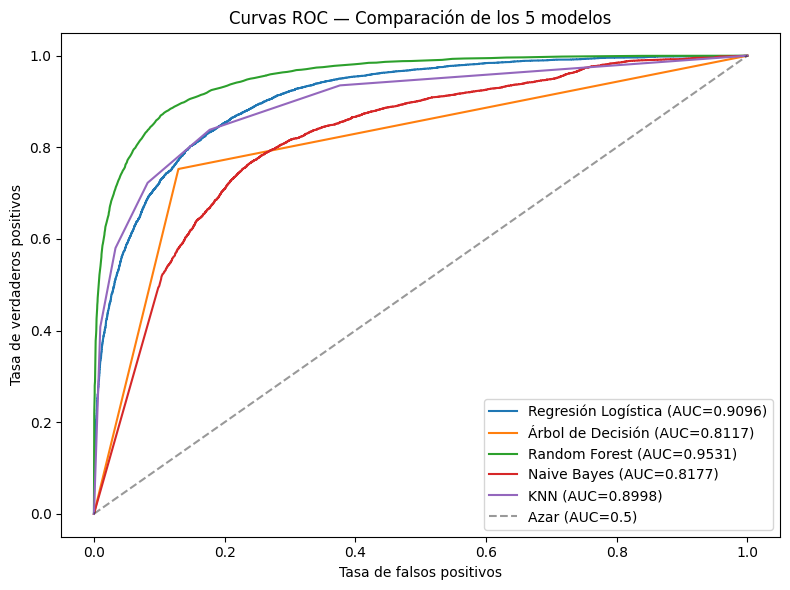

In [36]:
#Curvas ROC de los 5 modelos
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, pipe in modelos_eval.items():
    y_prob = pipe.predict_proba(X_test_r)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — Comparación de los 5 modelos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

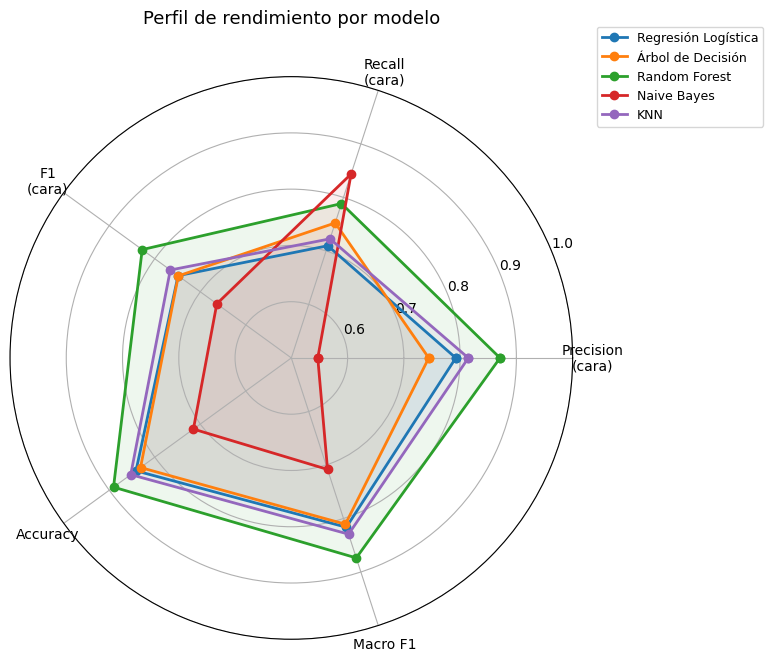

In [37]:
#Radar chart: precision cara, recall cara, f1 cara, accuracy, macro_f1 normalizados
from matplotlib.patches import FancyBboxPatch

categorias = ["Precision\n(cara)", "Recall\n(cara)", "F1\n(cara)", "Accuracy", "Macro F1"]
N = len(categorias)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores_radar = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for idx, row in df_reporte_clases.iterrows():
    valores = [row["precision_cara"], row["recall_cara"], row["f1_cara"],
               row["accuracy"], row["macro_f1"]]
    valores += valores[:1]
    ax.plot(angulos, valores, "o-", label=row["modelo"], color=colores_radar[idx], linewidth=2)
    ax.fill(angulos, valores, alpha=0.08, color=colores_radar[idx])

ax.set_thetagrids(np.degrees(angulos[:-1]), categorias)
ax.set_ylim(0.5, 1.0)
ax.set_title("Perfil de rendimiento por modelo", y=1.08, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

In [38]:
#Tabla resumen final con ranking por métrica
resumen_ranking = df_comparacion_5[["modelo", "accuracy", "f1_cara", "roc_auc",
                                     "errores_totales", "tiempo_total_seg"]].copy()
resumen_ranking["rank_accuracy"] = resumen_ranking["accuracy"].rank(ascending=False).astype(int)
resumen_ranking["rank_f1"] = resumen_ranking["f1_cara"].rank(ascending=False).astype(int)
resumen_ranking["rank_auc"] = resumen_ranking["roc_auc"].rank(ascending=False).astype(int)
resumen_ranking["rank_errores"] = resumen_ranking["errores_totales"].rank(ascending=True).astype(int)
resumen_ranking["rank_tiempo"] = resumen_ranking["tiempo_total_seg"].rank(ascending=True).astype(int)
resumen_ranking["rank_promedio"] = resumen_ranking[["rank_accuracy", "rank_f1", "rank_auc",
                                                      "rank_errores", "rank_tiempo"]].mean(axis=1)
resumen_ranking = resumen_ranking.sort_values("rank_promedio")
resumen_ranking[["modelo", "rank_accuracy", "rank_f1", "rank_auc",
                 "rank_errores", "rank_tiempo", "rank_promedio"]]

,modelo,rank_accuracy,rank_f1,rank_auc,rank_errores,rank_tiempo,rank_promedio
2,Random Forest,1,1,1,1,5,1.8
4,KNN,2,2,3,2,3,2.4
0,Regresión Logística,3,3,2,3,2,2.6
3,Naive Bayes,5,5,4,5,1,4.0
1,Árbol de Decisión,4,4,5,4,4,4.2


### Observaciones y conclusiones del inciso 12

El ranking promedio posiciona a **Random Forest** como el mejor modelo con un puntaje de 1.8, seguido de KNN (2.4), Regresión Logística (2.6), Naive Bayes (4.0) y Árbol de Decisión (4.2). Random Forest ocupa el primer lugar en accuracy (0.8906), F1 para la clase cara (0.8276), AUC (0.9531) y menor cantidad de errores totales (2,503). Su único punto débil es el tiempo: fue el más lento de los cinco (1.76 s), aunque en términos absolutos sigue siendo un tiempo perfectamente manejable.

Desde la perspectiva de **precisión por clase**, la diferencia más importante está en cómo cada modelo balancea las dos clases. Para la clase "no cara", Random Forest logra el mejor F1 (0.9198) con un recall de 0.9416, lo que significa que casi no deja pasar viviendas baratas como si fueran caras. Para la clase "cara", también lidera con precision de 0.8709 y recall de 0.7885. Naive Bayes presenta el caso opuesto: tiene el recall más alto para la clase cara (0.8437), pero su precision es tan baja (0.5470) que prácticamente la mitad de lo que marca como "cara" no lo es. Eso lo vuelve inútil en la práctica si el costo de un falso positivo importa.

La **curva ROC** confirma la superioridad de Random Forest: su curva se mantiene más pegada a la esquina superior izquierda que las demás, y su AUC de 0.9531 indica una capacidad de discriminación excelente. La Regresión Logística le sigue con 0.9096, lo cual es notable para un modelo lineal. El Árbol de Decisión tiene la curva ROC más escalonada y el AUC más bajo (0.8117), reflejando que sus probabilidades son menos calibradas al ser un modelo que solo produce estimaciones discretas por hoja.

En cuanto a **tiempo de entrenamiento**, Naive Bayes es imbatible (0.10 s) y KNN casi no entrena (0.06 s), pero este último paga el costo en predicción (1.12 s). La Regresión Logística ofrece un buen compromiso: entrena en 0.36 s y predice en 0.02 s, lo que la hace ideal si se necesita un modelo rápido con performance decente.

En conclusión, si lo que se busca es **máxima precisión** para identificar viviendas caras, Random Forest es la elección clara. Si se necesita un modelo **rápido, interpretable y con buen rendimiento**, la Regresión Logística es la mejor alternativa. KNN queda como opción intermedia, pero su lentitud en predicción lo penaliza. Naive Bayes y Árbol de Decisión no ofrecen ventajas competitivas frente a los anteriores en este problema particular.